#### Importing the required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

#### Extracting the pre-processed data

In [ ]:
# Loading pre-processed data from the CSV file

df_model = pd.read_csv('../data/wc_2022_processed_striker_data.csv', index_col='player')
print(df_model.head())

                   Goals  Total_xG  Avg_xG_per_Shot  Shot_Count  G_minus_xG  \
player                                                                        
Gue-Sung Cho           2  0.712589         0.089074           8    1.287411   
Olivier Giroud         4  3.035955         0.178586          17    0.964045   
Youssef En-Nesyri      2  1.045874         0.095079          11    0.954126   
Julián Álvarez         4  1.908327         0.173484          11    2.091673   
Bruno Petković         1  0.099778         0.099778           1    0.900222   

                   Aerial_Duels_Won  Aerial_Duels_Total  Aerial_Pass_Wins  \
player                                                                      
Gue-Sung Cho                      0                   0                16   
Olivier Giroud                    0                   0                18   
Youssef En-Nesyri                 0                   0                15   
Julián Álvarez                    3                   0      

In [ ]:
# Narrowing down the dataframe to only include required features

features = ['scaled_Goals_p90', 'scaled_Total_xG_p90', 
            'scaled_Total_Aerial_Wins_p90', 'scaled_G_minus_xG']

X = df_model[features]

print(X.head())

                   scaled_Goals_p90  scaled_Total_xG_p90  \
player                                                     
Gue-Sung Cho               0.421918             0.179955   
Olivier Giroud             0.641667             0.597545   
Youssef En-Nesyri          0.280510             0.175443   
Julián Álvarez             0.512479             0.296749   
Bruno Petković             0.137746             0.010554   

                   scaled_Total_Aerial_Wins_p90  scaled_G_minus_xG  
player                                                              
Gue-Sung Cho                           0.845401           0.542170  
Olivier Giroud                         0.723214           0.487253  
Youssef En-Nesyri                      0.526932           0.485569  
Julián Álvarez                         0.192536           0.678757  
Bruno Petković                         0.483005           0.476414  


#### K-Means Clustering

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

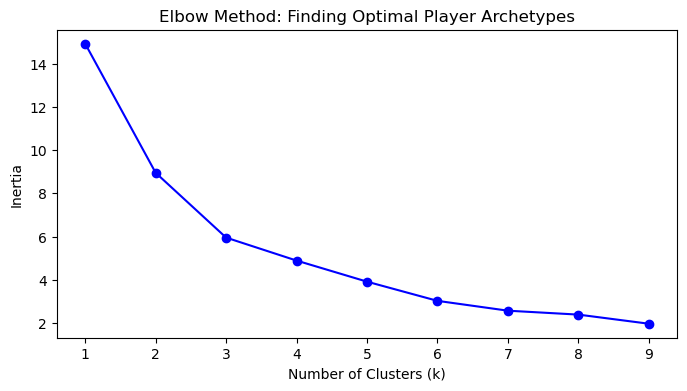

In [ ]:
# Finding the optimal number of clusters

inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Finding Optimal Player Archetypes')
plt.show()

In [9]:
# Apply KMeans with the mathematically optimal 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model['Cluster'] = kmeans.fit_predict(X)

cluster_summary = df_model.groupby('Cluster')[features].mean()

print("--- Refined Tactical Archetypes (k=3) ---")
print(cluster_summary)

--- Refined Tactical Archetypes (k=3) ---
         scaled_Goals_p90  scaled_Total_xG_p90  scaled_Total_Aerial_Wins_p90  \
Cluster                                                                        
0                0.610212             0.468563                      0.182312   
1                0.064124             0.157925                      0.141235   
2                0.294468             0.318225                      0.755266   

         scaled_G_minus_xG  
Cluster                     
0                 0.513039  
1                 0.286984  
2                 0.353036  


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [12]:
# Naming the cluster

cluster_names = {
    0: 'Elite Finisher',
    1: 'Support Forward',
    2: 'Aerial Hub'
}

df_model['Archetype'] = df_model['Cluster'].map(cluster_names)

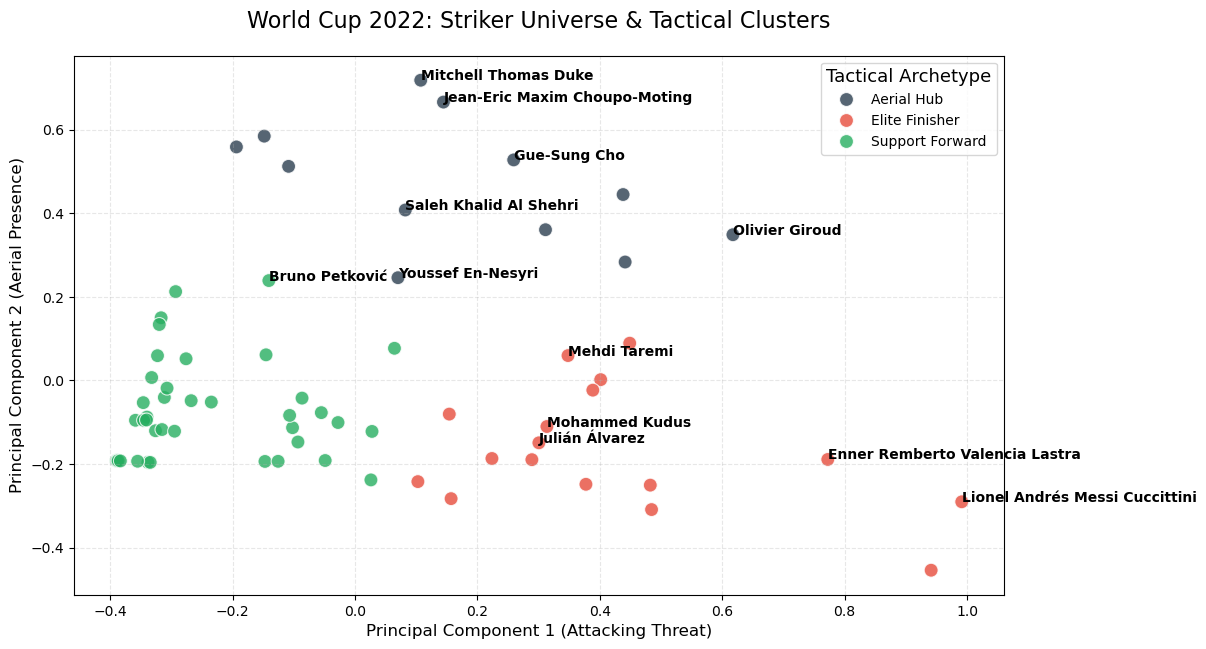

In [13]:
# Visualizing the clusters

pca = PCA(n_components=2)
pca_results = pca.fit_transform(X)

df_model['PCA1'] = pca_results[:, 0]
df_model['PCA2'] = pca_results[:, 1]

plt.figure(figsize=(12, 7))
palette = {'Aerial Hub': '#2c3e50', 'Elite Finisher': '#e74c3c', 'Support Forward': '#27ae60'}
sns.scatterplot(data=df_model, x='PCA1', y='PCA2', hue='Archetype', 
                palette=palette, s=100, alpha=0.8)

texts = []
top_targets = df_model.sort_values('Smart_Scout_Score', ascending=False).head(12).index

for i, txt in enumerate(df_model.index):
    if txt in top_targets:
        # Create labels for high-value targets only
        texts.append(plt.text(df_model.PCA1.iloc[i], df_model.PCA2.iloc[i], txt, 
                              fontsize=10, fontweight='bold'))


plt.title('World Cup 2022: Striker Universe & Tactical Clusters', fontsize=16, pad=20)
plt.xlabel('Principal Component 1 (Attacking Threat)', fontsize=12)
plt.ylabel('Principal Component 2 (Aerial Presence)', fontsize=12)
plt.legend(title='Tactical Archetype', title_fontsize='13', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

#### Drawing insights

In [ ]:
# Shortlisting targets

priority_archetypes = ['Elite Finisher', 'Aerial Hub']

shortlist = df_model[df_model['Archetype'].isin(priority_archetypes)].copy()
shortlist_sorted = shortlist.sort_values(by=['Archetype', 'Smart_Scout_Score'], ascending=[True, False])

print("--- STRATEGIC RECRUITMENT SHORTLIST ---")
for archetype in priority_archetypes:
    print(f"\nTarget Profile: {archetype}")
    display_cols = ['Total_Minutes', 'Goals_p90', 'Total_Aerial_Wins_p90', 'Smart_Scout_Score']
    top_5 = shortlist_sorted[shortlist_sorted['Archetype'] == archetype].head(5)
    print(top_5[display_cols])

df_model.to_csv('../data/wc_2022_scouting_model_results.csv')